In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [34]:
df=pd.read_csv(r"C:\Users\kc584\OneDrive\Documents\New folder\Tic tac initial results.csv")
df.head()

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,MOVE6,MOVE7,CLASS
0,0,8,1,3,?,?,?,loss
1,4,7,2,6,?,?,?,win
2,0,8,1,6,5,?,?,draw
3,4,7,2,3,?,?,?,draw
4,0,4,2,1,?,?,?,win


In [35]:
df.shape

(2436, 8)

In [36]:
df['CLASS'].value_counts()

CLASS
draw    1134
loss     651
win      651
Name: count, dtype: int64

In [37]:
df.describe()

,MOVE1
count,2436.000000
mean,3.701149
std,2.326566
min,0.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,8.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2436 entries, 0 to 2435
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   MOVE1   2436 non-null   int64 
 1   MOVE2   2436 non-null   object
 2   MOVE3   2436 non-null   object
 3   MOVE4   2436 non-null   object
 4   MOVE5   2436 non-null   object
 5   MOVE6   2436 non-null   object
 6   MOVE7   2436 non-null   object
 7   CLASS   2436 non-null   object
dtypes: int64(1), object(7)
memory usage: 152.4+ KB


In [39]:
df['MOVE3'] = pd.to_numeric(df['MOVE3'], errors='coerce').astype('Int64')
df['MOVE4']=pd.to_numeric(df['MOVE4'], errors='coerce').astype('Int64')
df['MOVE2']=pd.to_numeric(df['MOVE2'], errors='coerce').astype('Int64')
df['MOVE5']=pd.to_numeric(df['MOVE5'], errors='coerce').astype('Int64')
df['MOVE6']=pd.to_numeric(df['MOVE6'], errors='coerce').astype('Int64')
df['MOVE7']=pd.to_numeric(df['MOVE7'], errors='coerce').astype('Int64')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2436 entries, 0 to 2435
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   MOVE1   2436 non-null   int64 
 1   MOVE2   2435 non-null   Int64 
 2   MOVE3   2218 non-null   Int64 
 3   MOVE4   1608 non-null   Int64 
 4   MOVE5   633 non-null    Int64 
 5   MOVE6   8 non-null      Int64 
 6   MOVE7   5 non-null      Int64 
 7   CLASS   2436 non-null   object
dtypes: Int64(6), int64(1), object(1)
memory usage: 166.7+ KB


In [41]:
df.head()

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,MOVE6,MOVE7,CLASS
0,0,8,1,3,<NA>,<NA>,<NA>,loss
1,4,7,2,6,<NA>,<NA>,<NA>,win
2,0,8,1,6,5,<NA>,<NA>,draw
3,4,7,2,3,<NA>,<NA>,<NA>,draw
4,0,4,2,1,<NA>,<NA>,<NA>,win


In [42]:
win_rows = df[df['CLASS'] == 'win']
loss_rows = df[df['CLASS'] == 'loss']
draw_rows = df[df['CLASS'] == 'draw']

In [43]:
win_rows

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,MOVE6,MOVE7,CLASS
1,4,7,2,6,<NA>,<NA>,<NA>,win
4,0,4,2,1,<NA>,<NA>,<NA>,win
9,4,0,8,<NA>,<NA>,<NA>,<NA>,win
10,4,6,1,7,<NA>,<NA>,<NA>,win
13,6,8,7,<NA>,<NA>,<NA>,<NA>,win
...,...,...,...,...,...,...,...,...
2426,2,8,4,0,<NA>,<NA>,<NA>,win
2429,8,6,7,<NA>,<NA>,<NA>,<NA>,win
2431,4,5,3,<NA>,<NA>,<NA>,<NA>,win
2433,4,5,7,1,<NA>,<NA>,<NA>,win


In [49]:
#LABEL ENCODING

In [50]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['CLASS'] = encoder.fit_transform(df['CLASS'])

print(df['CLASS'].head())

0    1
1    2
2    0
3    0
4    2
Name: CLASS, dtype: int64


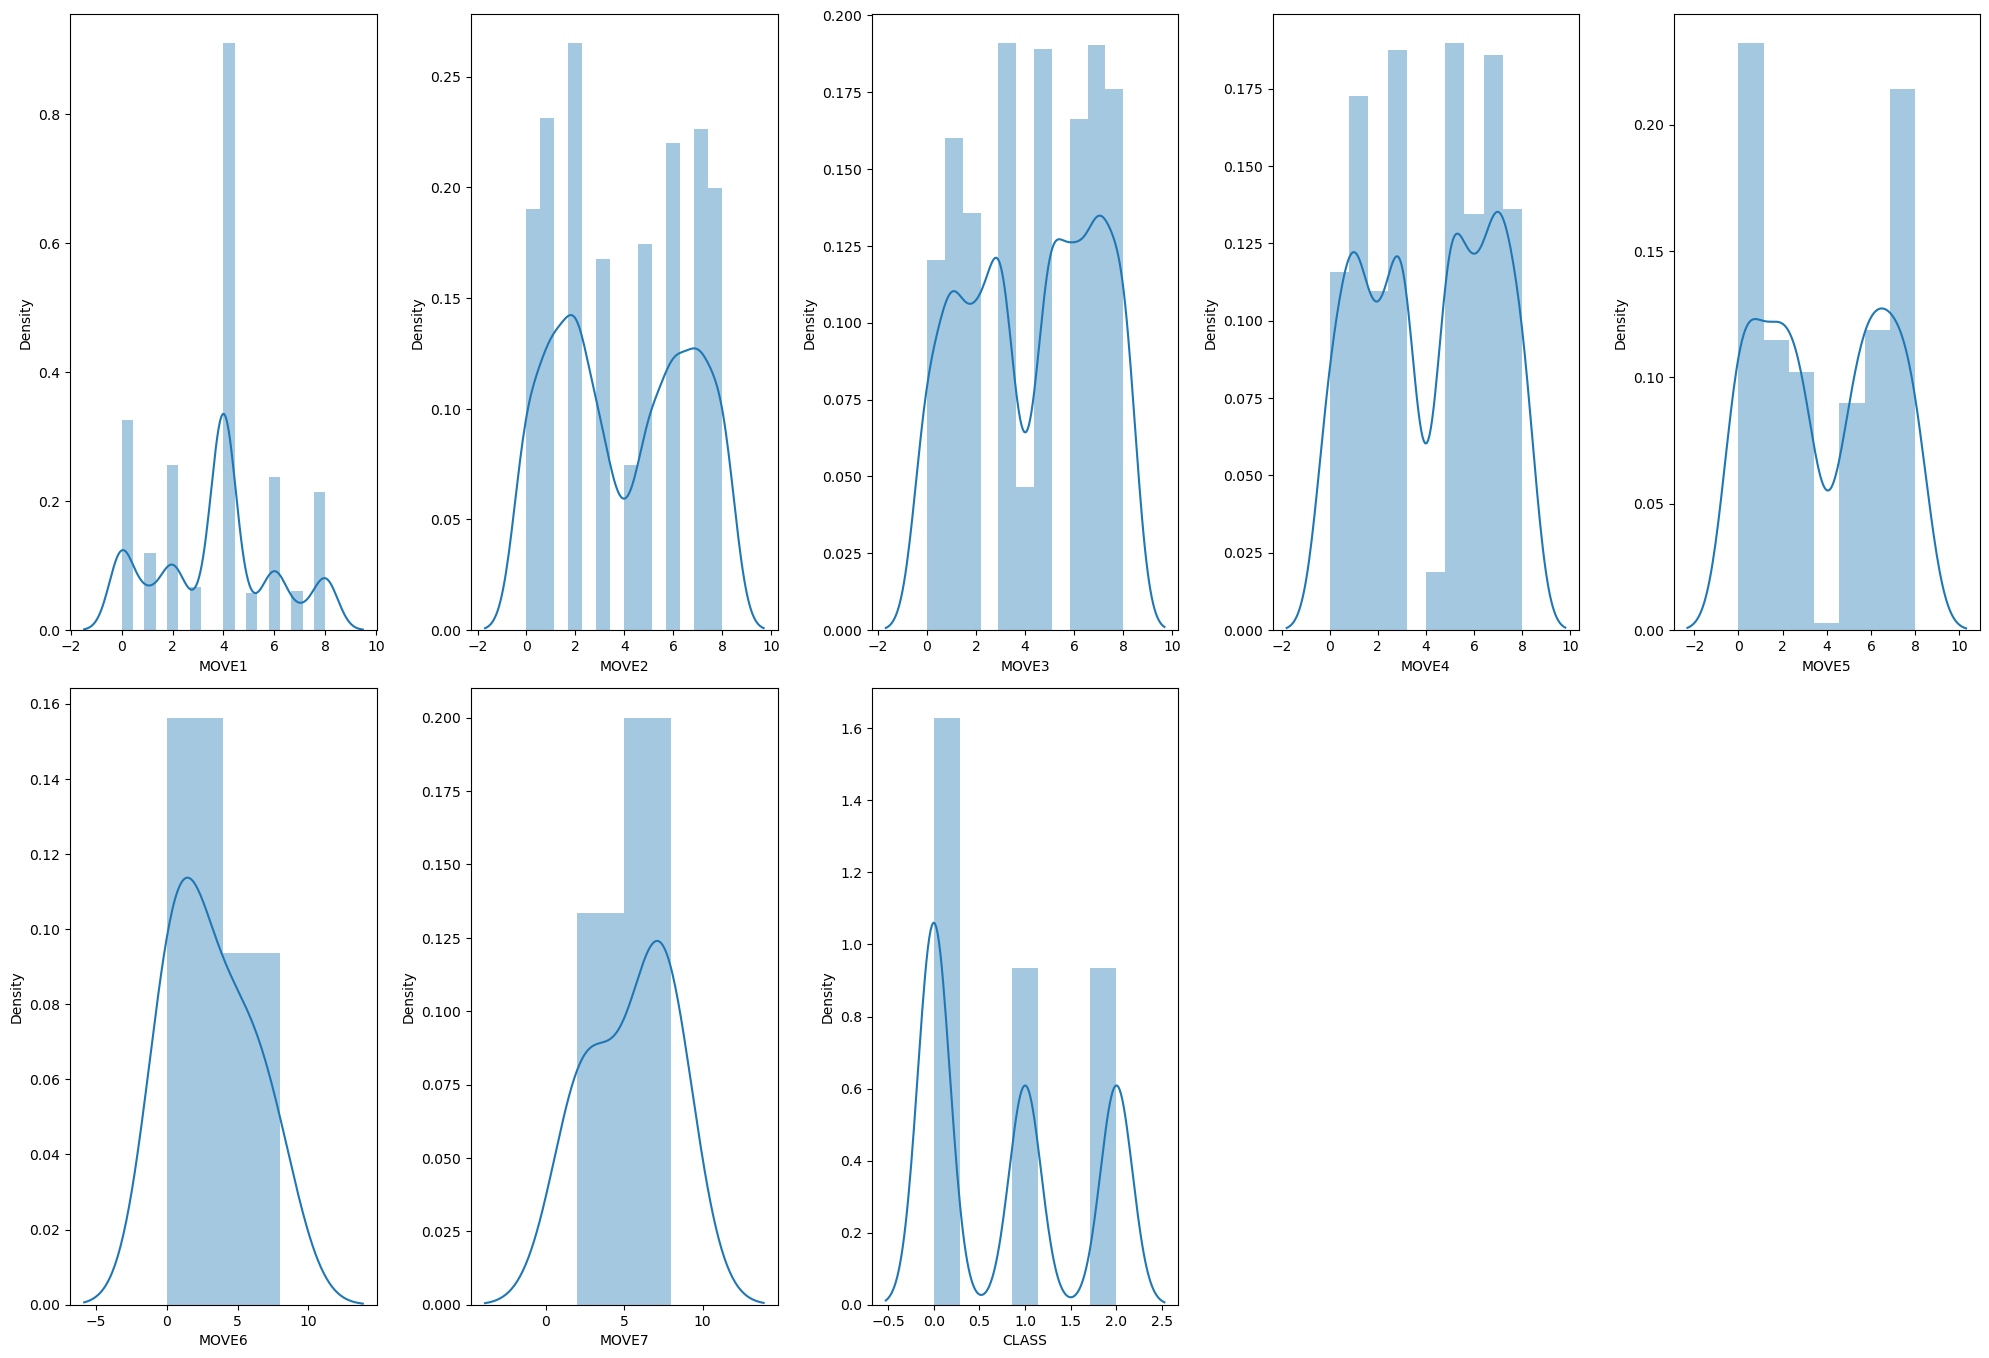

In [51]:
plt.figure(figsize = (20, 20))
plotnumber = 1

for column in win_rows:
    if plotnumber <= 651:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

In [52]:
df.corr()

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,MOVE6,MOVE7,CLASS
MOVE1,1.000000,-0.125809,-0.150269,-0.086347,-0.193949,-0.616175,-0.473016,-0.001133
MOVE2,-0.125809,1.000000,-0.303117,-0.089234,-0.205264,-0.340109,-0.241287,0.047550
MOVE3,-0.150269,-0.303117,1.000000,-0.312551,-0.044221,0.074140,0.544394,0.073334
MOVE4,-0.086347,-0.089234,-0.312551,1.000000,-0.180518,-0.030750,-0.584536,-0.055176
MOVE5,-0.193949,-0.205264,-0.044221,-0.180518,1.000000,0.420822,0.589041,-0.069736
MOVE6,-0.616175,-0.340109,0.074140,-0.030750,0.420822,1.000000,0.735889,0.297500
MOVE7,-0.473016,-0.241287,0.544394,-0.584536,0.589041,0.735889,1.000000,-0.376018
CLASS,-0.001133,0.047550,0.073334,-0.055176,-0.069736,0.297500,-0.376018,1.000000


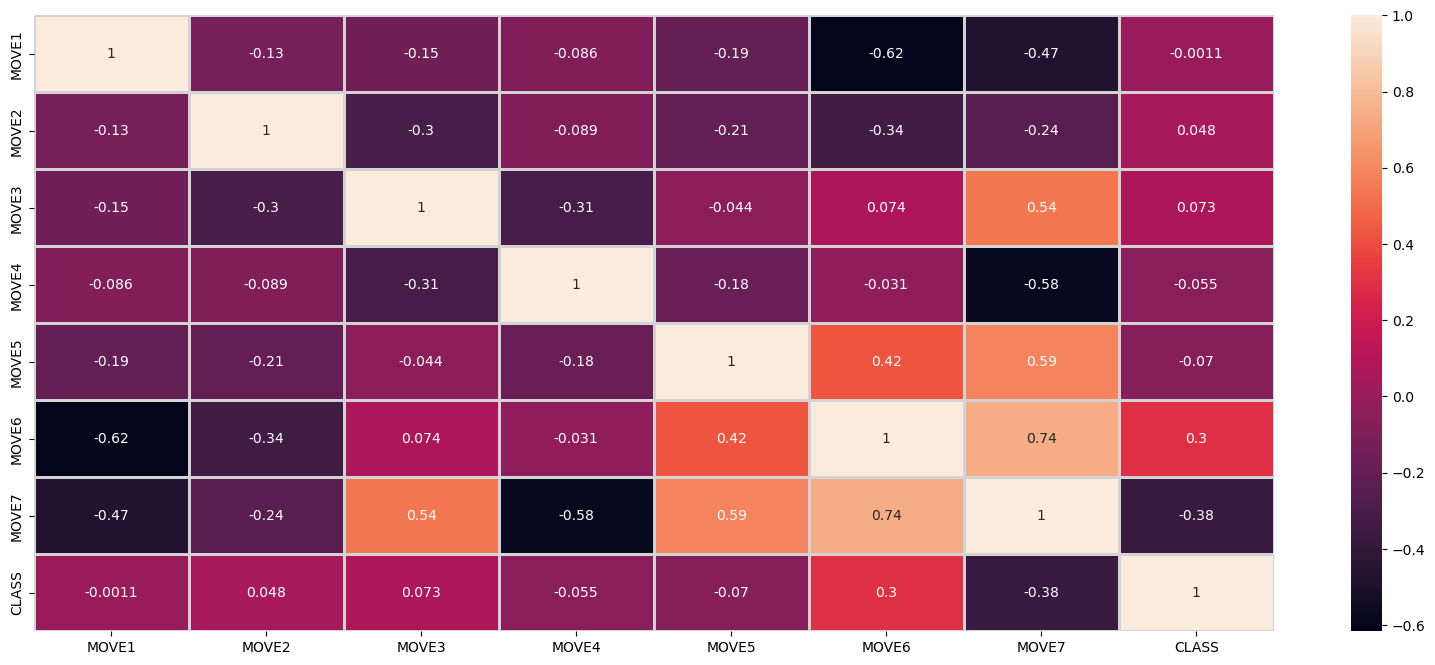

In [53]:
plt.figure(figsize = (20,8))
sns.heatmap(df.corr(), annot=True, linewidth=2, linecolor = 'lightgray')
plt.show()

In [54]:
#DATA PREPROCESSING

In [55]:
# checking for missing value
df.isnull().sum()

MOVE1       0
MOVE2       1
MOVE3     218
MOVE4     828
MOVE5    1803
MOVE6    2428
MOVE7    2431
CLASS       0
dtype: int64

In [58]:
#WE choose Random Sampling
for col in df.columns:
    df[col].fillna(df[col].mode()[9], inplace=True)

In [59]:
df.isnull().sum()

MOVE1    0
MOVE2    0
MOVE3    0
MOVE4    0
MOVE5    0
MOVE6    0
MOVE7    0
CLASS    0
dtype: int64

In [60]:
df.head(10)

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,MOVE6,MOVE7,CLASS
0,0,8,1,3,3,0,7,1
1,4,7,2,6,3,0,7,2
2,0,8,1,6,5,0,7,0
3,4,7,2,3,3,0,7,0
4,0,4,2,1,3,0,7,2
5,8,5,6,5,3,0,7,1
6,0,2,7,5,6,0,7,0
7,4,1,3,8,3,0,7,0
8,2,6,7,5,3,0,7,1
9,4,0,8,5,3,0,7,2


In [61]:
# MODEL BUILDING

In [62]:
df.columns

Index(['MOVE1', 'MOVE2', 'MOVE3', 'MOVE4', 'MOVE5', 'MOVE6', 'MOVE7', 'CLASS'], dtype='object')

In [63]:
X = df.drop('CLASS', axis = 1)
y = df['CLASS']

In [64]:
y

0       1
1       2
2       0
3       0
4       2
       ..
2431    2
2432    1
2433    2
2434    1
2435    2
Name: CLASS, Length: 2436, dtype: int64

In [65]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
# Feature Scaling (important for KNN and SVM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
# DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(f"Training Accuracy of DTC is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Testing Accuracy of DTC is {accuracy_score(y_test, dtc.predict(X_test))}")

print(f"Confusion Matrix of DTC is \n {confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report of DTC is \n{classification_report(y_test, dtc.predict(X_test))}")

Training Accuracy of DTC is 0.8968172484599589
Testing Accuracy of DTC is 0.7377049180327869
Confusion Matrix of DTC is 
 [[221   9   6]
 [ 20  80  26]
 [ 13  54  59]]

Classification Report of DTC is 
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       236
           1       0.56      0.63      0.59       126
           2       0.65      0.47      0.54       126

    accuracy                           0.74       488
   macro avg       0.69      0.68      0.68       488
weighted avg       0.73      0.74      0.73       488



In [73]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = "gini", max_depth = 10, max_features="sqrt", min_samples_leaf= 1, min_samples_split= 7, n_estimators = 400)
rand_clf.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,10
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
rand_clf_acc = accuracy_score(y_test, rand_clf.predict(X_test))
print(f"Training Accuracy of Random Forest is {accuracy_score(y_train, rand_clf.predict(X_train))}")
print(f"Testing Accuracy of Random Forest is {accuracy_score(y_test, rand_clf.predict(X_test))}")

print(f"Confusion Matrix of Random Forest is \n {confusion_matrix(y_test, rand_clf.predict(X_test))}\n")
print(f"Classification Report of Random Forest is \n{classification_report(y_test, rand_clf.predict(X_test))}")

Training Accuracy of Random Forest is 0.824435318275154
Testing Accuracy of Random Forest is 0.7213114754098361
Confusion Matrix of Random Forest is 
 [[221   6   9]
 [ 29  63  34]
 [ 19  39  68]]

Classification Report of Random Forest is 
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       236
           1       0.58      0.50      0.54       126
           2       0.61      0.54      0.57       126

    accuracy                           0.72       488
   macro avg       0.67      0.66      0.66       488
weighted avg       0.71      0.72      0.71       488



In [75]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Training Accuracy of LR is {accuracy_score(y_train, lr.predict(X_train))}")
print(f"Testing Accuracy of LR is {accuracy_score(y_test, lr.predict(X_test))}")

print(f"Confusion Matrix of LR is \n {confusion_matrix(y_test, lr.predict(X_test))}\n")
print(f"Classification Report of LR is \n{classification_report(y_test, lr.predict(X_test))}")

Training Accuracy of LR is 0.45790554414784396
Testing Accuracy of LR is 0.45081967213114754
Confusion Matrix of LR is 
 [[191  17  28]
 [108   0  18]
 [ 96   1  29]]

Classification Report of LR is 
              precision    recall  f1-score   support

           0       0.48      0.81      0.61       236
           1       0.00      0.00      0.00       126
           2       0.39      0.23      0.29       126

    accuracy                           0.45       488
   macro avg       0.29      0.35      0.30       488
weighted avg       0.33      0.45      0.37       488



In [78]:
# Models KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [79]:
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"Training Accuracy of KNN is {accuracy_score(y_train, knn.predict(X_train))}")
print(f"Testing Accuracy of KNN is {accuracy_score(y_test, knn.predict(X_test))}")

print(f"Confusion Matrix of KNN is \n {confusion_matrix(y_test, knn.predict(X_test))}\n")
print(f"Classification Report of KNN is \n{classification_report(y_test, knn.predict(X_test))}")

Training Accuracy of KNN is 0.7777207392197125
Testing Accuracy of KNN is 0.7049180327868853
Confusion Matrix of KNN is 
 [[216  10  10]
 [ 38  64  24]
 [ 22  40  64]]

Classification Report of KNN is 
              precision    recall  f1-score   support

           0       0.78      0.92      0.84       236
           1       0.56      0.51      0.53       126
           2       0.65      0.51      0.57       126

    accuracy                           0.70       488
   macro avg       0.67      0.64      0.65       488
weighted avg       0.69      0.70      0.69       488



In [80]:
# Model Comparison

models = pd.DataFrame({
    'Model':['Logistic Regression', 'KNN', 'DT', 'Random Forest Classifier'],
    'Score':[lr_acc, knn_acc, dtc_acc, rand_clf_acc]
})

models.sort_values(by='Score', ascending = False)

,Model,Score
2,DT,0.737705
3,Random Forest Classifier,0.721311
1,KNN,0.704918
0,Logistic Regression,0.450820


In [81]:
import pickle
model = dtc_acc
pickle.dump(model, open("tictactoe.pkl", 'wb'))